In [1]:
import pandas as pd
import datetime as dt
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.feature_extraction import DictVectorizer

In [3]:
df_train = pd.read_parquet('../data/green_tripdata_2021-01.parquet')
df_val = pd.read_parquet('../data/green_tripdata_2021-02.parquet')

In [4]:
df_train['duration'] = (
    df_train['lpep_dropoff_datetime'] - df_train['lpep_pickup_datetime']
).dt.total_seconds() / 60

In [5]:
df_val['duration'] = (
    df_val['lpep_dropoff_datetime'] - df_val['lpep_pickup_datetime']
).dt.total_seconds() / 60

In [6]:
df_train = df_train[ (df_train['duration'] >= 1) & (df_train['duration'] <= 60) ]

In [7]:
df_val = df_val[ (df_val['duration'] >= 1) & (df_val['duration'] <= 60) ]

In [8]:
categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient = 'records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient = 'records')
X_val = dv.fit_transform(val_dicts)

In [9]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_val)
rmse = root_mean_squared_error(y_val,y_pred)
print(rmse)

12.078673198609525


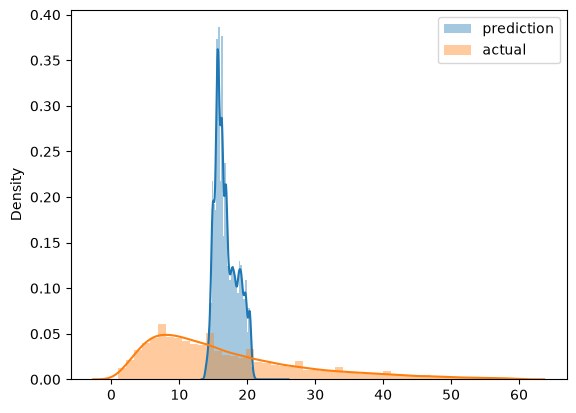

In [12]:
import warnings
warnings.filterwarnings('ignore')

sns.distplot(y_pred, label='prediction')
sns.distplot(y_train, label='actual')

plt.legend()
plt.show()